# Anomaly Forecast

### Imports and settings

In [1]:
import pandas as pd                                                    # tables
import numpy as np                                                     # maths
import matplotlib.pyplot as plt                                        # charts
from statsmodels.tsa.seasonal import STL                               # splits a series into trend + weekly pattern + leftover
from statsmodels.tsa.exponential_smoothing.ets import ETSModel         # exponential smoothing forecast with intervals
from pathlib import Path                                               # file paths

pd.set_option("display.max_columns", None)                             # never hide columns
pd.set_option("display.width", 200)                                    # wide printing

### Paths and a clean daily series

In [2]:
ROOT = Path.cwd()                                                      # folder the notebook runs in
if ROOT.name == "notebooks":                                           # if inside notebooks/...
    ROOT = ROOT.parent                                                 # ...go up to the project root
DATA = ROOT / "data" / "processed"                                     # data folder
FIG = ROOT / "reports" / "figures"                                     # charts folder
kpi = pd.read_csv(DATA / "kpi_daily.csv", parse_dates=["day"]).sort_values("day").set_index("day")   # one row per day
for col in kpi.columns:                                                # one loop, one column per iteration
    if col != "has_full_28d_window":                                   # that column is a True/False flag
        kpi[col] = pd.to_numeric(kpi[col], errors="coerce")            # make sure every metric is a number, not text
RAMP_UP_DAYS = 14                                                       # the first days of any export are a ramp-up, not normal behaviour
dau = kpi["dau"].iloc[RAMP_UP_DAYS:].asfreq("D")                        # drop the ramp-up, then make sure every calendar day exists
print("Missing days filled by interpolation:", int(dau.isna().sum()))  # should usually be 0
dau = dau.interpolate()                                                # fill any gap with a straight line
print(dau.describe().round(1))                                         # quick summary

Missing days filled by interpolation: 0
count    100.0
mean     470.3
std       85.5
min      333.0
25%      428.0
50%      457.0
75%      488.2
max      835.0
Name: dau, dtype: float64


### STL decomposition with a 7-day season

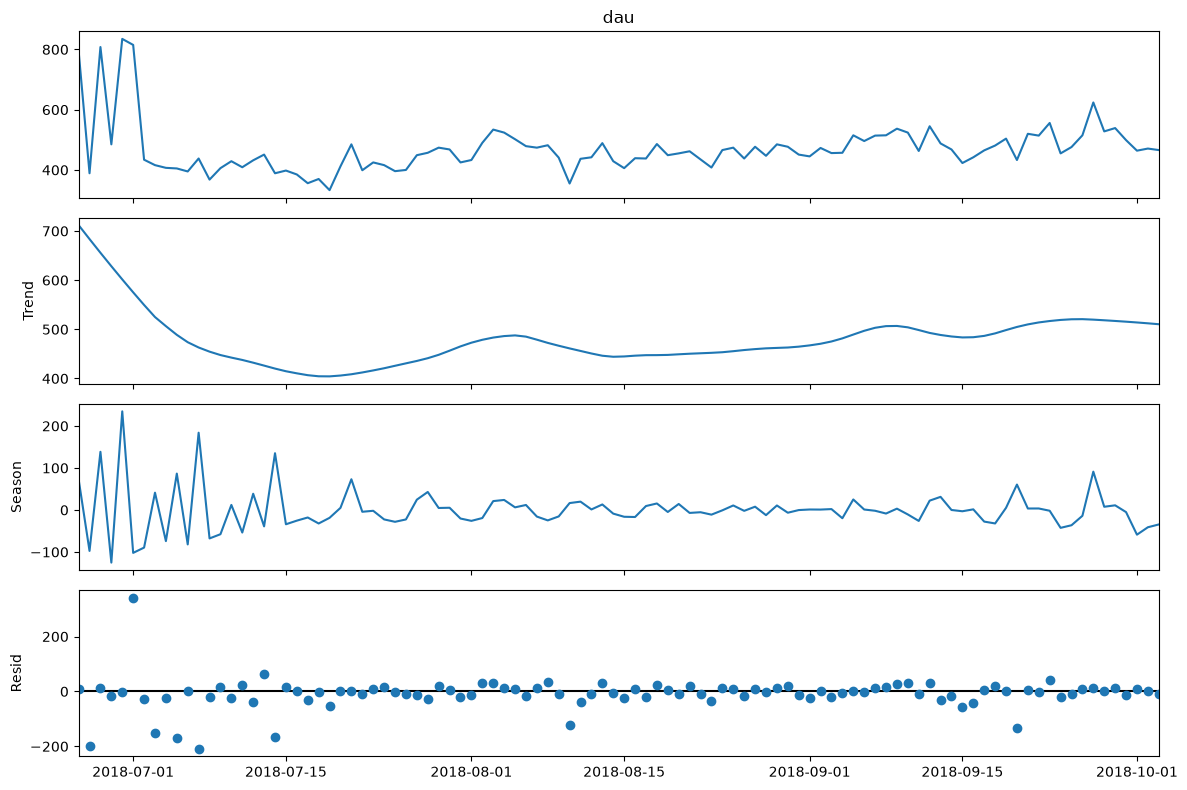

In [3]:
stl = STL(dau, period=7, robust=True).fit()                            # robust = unusual days do not distort the trend
fig = stl.plot()                                                       # four panels: observed, trend, season, residual
fig.set_size_inches(12, 8)                                             # bigger chart
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "19_stl_decomposition.png", dpi=150)                 # save
plt.show()                                                             # display

### Flag anomalies with a robust z-score on the residual

Analysis window: 2018-06-26 to 2018-10-03 (100 days, first 14 days excluded as ramp-up)
Flagged 8 of 100 days
            dau  expected  robust_z
day                                
2018-06-27  389    586.16     -8.43
2018-07-01  815    473.16     14.80
2018-07-03  416    566.22     -6.41
2018-07-05  405    575.40     -7.28
2018-07-07  438    647.04     -8.94
2018-07-14  389    555.29     -7.10
2018-08-10  355    477.66     -5.22
2018-09-20  433    565.36     -5.64


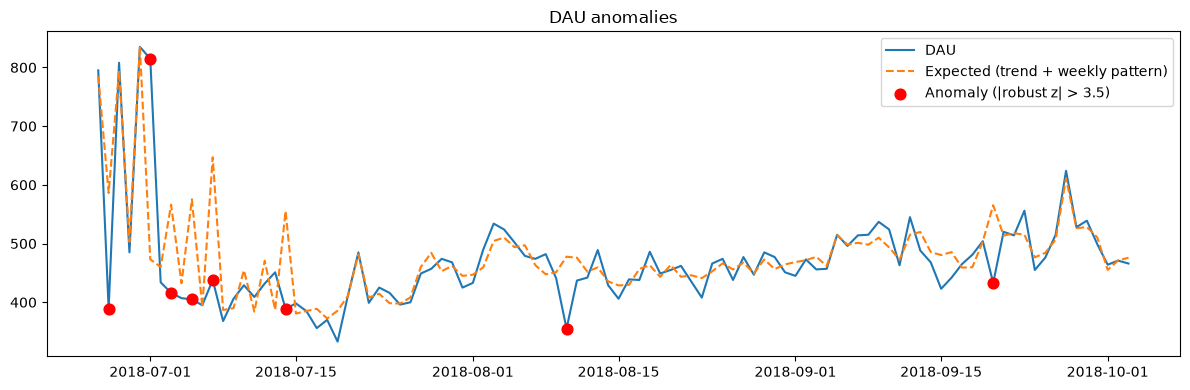

In [4]:
resid = stl.resid                                                      # what the trend and weekly pattern cannot explain
mad = np.median(np.abs(resid - np.median(resid)))                      # median absolute deviation (robust spread)
robust_z = (resid - np.median(resid)) / (1.4826 * mad)                 # 1.4826 makes MAD comparable to a standard deviation
anomalies = pd.DataFrame({"dau": dau, "expected": stl.trend + stl.seasonal, "robust_z": robust_z})   # observed vs expected
anomalies = anomalies[anomalies["robust_z"].abs() > 3.5]               # common cut-off for strong outliers
print(f"Analysis window: {dau.index.min().date()} to {dau.index.max().date()} ({len(dau)} days, first {RAMP_UP_DAYS} days excluded as ramp-up)")
print(f"Flagged {len(anomalies)} of {len(dau)} days")                   # how many days were unusual
print(anomalies.round(2))                                              # the flagged days
fig, ax = plt.subplots(figsize=(12, 4))                                # empty chart
ax.plot(dau.index, dau.values, label="DAU")                            # series
ax.plot(dau.index, stl.trend + stl.seasonal, linestyle="--", label="Expected (trend + weekly pattern)")   # expected level
ax.scatter(anomalies.index, anomalies["dau"], color="red", zorder=3, s=60, label="Anomaly (|robust z| > 3.5)")   # red dots
ax.legend()                                                            # legend
ax.set_title("DAU anomalies")                                          # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "20_dau_anomalies.png", dpi=150)                     # save
plt.show()                                                             # display

### Diagnose each anomaly: tracking problem or real behaviour change?

In [5]:
ratio_cols = ["sessions_per_dau", "minutes_per_dau", "levels_per_dau"]  # per-player behaviour
typical = kpi[ratio_cols].median()                                     # normal level of each ratio
for day in anomalies.index:                                            # one loop, one anomaly per iteration
    ratios = (kpi.loc[day, ratio_cols].astype(float) / typical).round(2)   # this day relative to normal (1.0 = normal); astype keeps it numeric
    print(day.date(), "| DAU vs expected:", round(anomalies.loc[day, "dau"] / anomalies.loc[day, "expected"], 2), "| per-player ratios vs normal:", ratios.to_dict())
print("Reading: DAU far below expected while per-player ratios stay near 1.0 usually means lost data (tracking), not players behaving differently.")

2018-06-27 | DAU vs expected: 0.66 | per-player ratios vs normal: {'sessions_per_dau': 1.05, 'minutes_per_dau': 1.5, 'levels_per_dau': 1.13}
2018-07-01 | DAU vs expected: 1.72 | per-player ratios vs normal: {'sessions_per_dau': 1.06, 'minutes_per_dau': 1.13, 'levels_per_dau': 1.04}
2018-07-03 | DAU vs expected: 0.73 | per-player ratios vs normal: {'sessions_per_dau': 1.07, 'minutes_per_dau': 1.33, 'levels_per_dau': 1.03}
2018-07-05 | DAU vs expected: 0.7 | per-player ratios vs normal: {'sessions_per_dau': 1.0, 'minutes_per_dau': 1.28, 'levels_per_dau': 1.21}
2018-07-07 | DAU vs expected: 0.68 | per-player ratios vs normal: {'sessions_per_dau': 1.02, 'minutes_per_dau': 1.26, 'levels_per_dau': 1.13}
2018-07-14 | DAU vs expected: 0.7 | per-player ratios vs normal: {'sessions_per_dau': 1.02, 'minutes_per_dau': 1.21, 'levels_per_dau': 1.26}
2018-08-10 | DAU vs expected: 0.74 | per-player ratios vs normal: {'sessions_per_dau': 0.97, 'minutes_per_dau': 1.23, 'levels_per_dau': 1.18}
2018-09-20

### Backtest: forecast the last 14 days and compare with a seasonal naive baseline

Seasonal naive: MAPE 7.70%, MAE 40.9 | ETS: MAPE 11.59%, MAE 62.8


C:\Users\AISHWARY\AppData\Local\Temp\ipykernel_17292\3025901705.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[586.16195432 473.16359196 566.22382521 575.40389273 647.03702101
 555.28542301 477.66017754 565.35574374]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  clean.loc[anomalies.index] = (stl.trend + stl.seasonal).loc[anomalies.index]   # replace anomalies with expected values before modeling


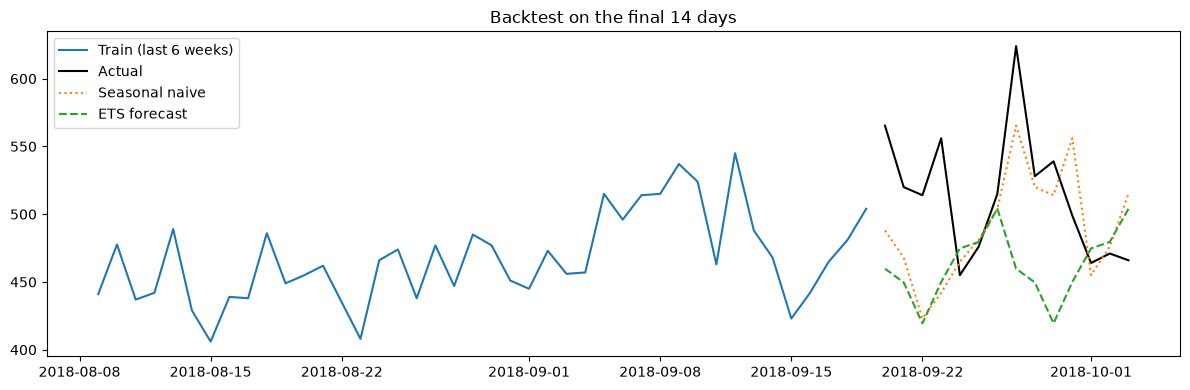

In [6]:
clean = dau.copy()                                                     # copy of the series
clean.loc[anomalies.index] = (stl.trend + stl.seasonal).loc[anomalies.index]   # replace anomalies with expected values before modeling
horizon = 14                                                           # days to forecast
train, test = clean.iloc[:-horizon], clean.iloc[-horizon:]             # hold out the final two weeks
naive = clean.shift(7).iloc[-horizon:]                                 # baseline: same weekday last week
ets = ETSModel(train, error="add", trend="add", damped_trend=True, seasonal="add", seasonal_periods=7).fit(disp=False)   # fit on train
ets_fc = ets.forecast(horizon)                                         # predict the held-out days
mape_naive = np.mean(np.abs((test - naive) / test)) * 100              # average % error of the baseline
mape_ets = np.mean(np.abs((test - ets_fc.values) / test)) * 100        # average % error of ETS
mae_naive = np.mean(np.abs(test - naive))                              # average absolute error of the baseline
mae_ets = np.mean(np.abs(test - ets_fc.values))                        # average absolute error of ETS
print(f"Seasonal naive: MAPE {mape_naive:.2f}%, MAE {mae_naive:.1f} | ETS: MAPE {mape_ets:.2f}%, MAE {mae_ets:.1f}")
fig, ax = plt.subplots(figsize=(12, 4))                                # empty chart
ax.plot(train.index[-42:], train.iloc[-42:], label="Train (last 6 weeks)")   # recent history
ax.plot(test.index, test, label="Actual", color="black")               # truth
ax.plot(test.index, naive, label="Seasonal naive", linestyle=":")      # baseline
ax.plot(test.index, ets_fc.values, label="ETS forecast", linestyle="--")   # model
ax.legend()                                                            # legend
ax.set_title("Backtest on the final 14 days")                          # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "21_forecast_backtest.png", dpi=150)                 # save
plt.show()                                                             # display

### Final 14-day forecast with 95% prediction intervals

             mean  pi_lower  pi_upper
2018-10-04  609.3     517.6     700.9
2018-10-05  513.8     420.4     607.2
2018-10-06  518.4     423.3     613.6
2018-10-07  488.6     391.7     585.4
2018-10-08  450.2     351.8     548.7
2018-10-09  459.9     359.8     560.1
2018-10-10  466.9     365.1     568.6
2018-10-11  609.3     473.2     745.3
2018-10-12  513.8     376.6     651.0
2018-10-13  518.4     380.0     656.8
2018-10-14  488.6     349.0     628.1
2018-10-15  450.2     309.5     591.0
2018-10-16  459.9     318.0     601.8
2018-10-17  466.8     323.8     609.9


C:\Users\AISHWARY\AppData\Local\Temp\ipykernel_17292\3229126399.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  start = clean.index[-1] + pd.Timedelta(days=1)                         # first future day
C:\Users\AISHWARY\AppData\Local\Temp\ipykernel_17292\3229126399.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  end = clean.index[-1] + pd.Timedelta(days=horizon)                     # last future day


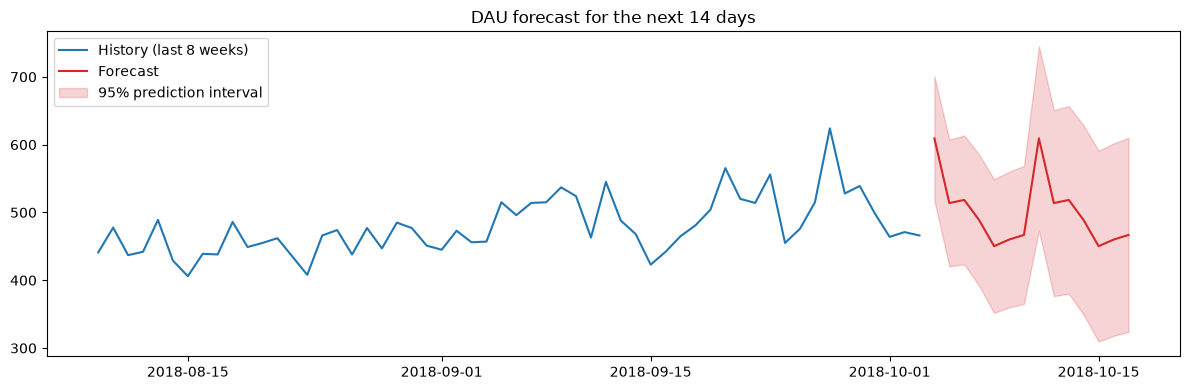

In [7]:
final_model = ETSModel(clean, error="add", trend="add", damped_trend=True, seasonal="add", seasonal_periods=7).fit(disp=False)   # refit on all data
start = clean.index[-1] + pd.Timedelta(days=1)                         # first future day
end = clean.index[-1] + pd.Timedelta(days=horizon)                     # last future day
future = final_model.get_prediction(start=start, end=end).summary_frame(alpha=0.05)   # mean and 95% interval
print(future.round(1))                                                 # table
fig, ax = plt.subplots(figsize=(12, 4))                                # empty chart
ax.plot(clean.index[-56:], clean.iloc[-56:], label="History (last 8 weeks)")   # history
ax.plot(future.index, future["mean"], label="Forecast", color="tab:red")        # forecast line
ax.fill_between(future.index, future["pi_lower"], future["pi_upper"], color="tab:red", alpha=0.2, label="95% prediction interval")   # uncertainty band
ax.legend()                                                            # legend
ax.set_title("DAU forecast for the next 14 days")                      # title
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "22_dau_forecast.png", dpi=150)                      # save
plt.show()                                                             # display
future.to_csv(DATA / "dau_forecast.csv")                               # save forecast
anomalies.to_csv(DATA / "dau_anomalies.csv")                           # save anomalies